<a href="https://colab.research.google.com/github/kswkm/AI_Colab/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [ ]:
#표 형태의 데이터
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


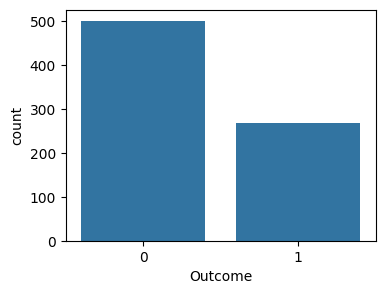

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
sns.countplot(x='Outcome', data=df)
plt.show()

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("Number of rows with 0 values for each variale")
for col in df.columns:
  missing_rows = df.loc[df[col] == 0].shape[0]
  print(col+": ", missing_rows)

Number of rows with 0 values for each variale
Pregnancies:  111
Glucose:  5
BloodPressure:  35
SkinThickness:  227
Insulin:  374
BMI:  11
DiabetesPedigreeFunction:  0
Age:  0
Outcome:  500


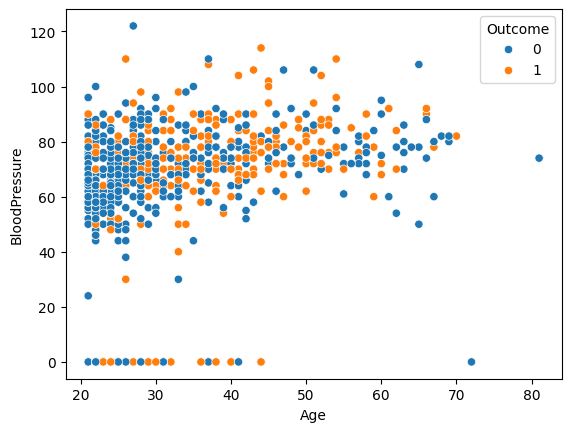

In [ ]:
sns.scatterplot(x='Age', y='BloodPressure', hue='Outcome', data=df)
plt.show()

In [12]:
cols = [c for c in df.columns if c != 'Outcome']

q1 = df[cols].quantile(0.25)
q3 = df[cols].quantile(0.75)

iqr = q3 - q1
iqr_15 = iqr * 1.5

lower = q1 - iqr_15
upper = q3 +iqr_15

In [15]:
iqr_data = pd.DataFrame({"속성": cols, "1사분위수": q1.values, "3사분위수": q3.values, "IQR*1.5": iqr_15.values, "최소값": lower.values, "최대값": upper.values})
display(iqr_data)

,속성,1사분위수,3사분위수,IQR*1.5,최소값,최대값
0,Pregnancies,1.00000,6.00000,7.50000,-6.500,13.500
1,Glucose,99.00000,140.25000,61.87500,37.125,202.125
2,BloodPressure,62.00000,80.00000,27.00000,35.000,107.000
3,SkinThickness,0.00000,32.00000,48.00000,-48.000,80.000
4,Insulin,0.00000,127.25000,190.87500,-190.875,318.125
5,BMI,27.30000,36.60000,13.95000,13.350,50.550
6,DiabetesPedigreeFunction,0.24375,0.62625,0.57375,-0.330,1.200
7,Age,24.00000,41.00000,25.50000,-1.500,66.500


<Axes: >

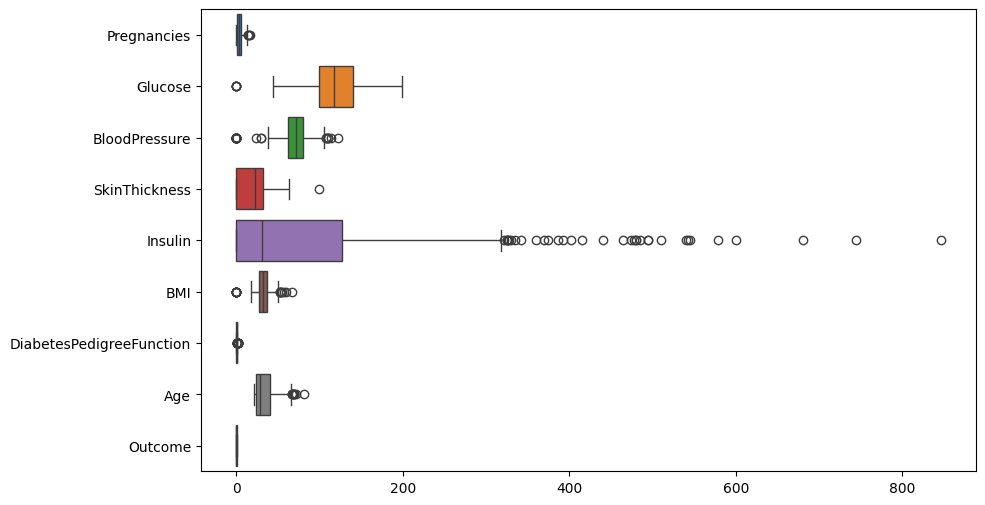

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient='h')

In [18]:
condition = pd.Series([True] * len(df))

for _, row in iqr_data.iterrows():
  col = row['속성']
  condition &= (df[col] >= row['최소값']) & (df[col] <= row['최대값'])

  df2 = df[condition]
  df2 = df2[(df2.SkinThickness>=1) & (df2.Insulin>=1)]
  display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181,88,44,510,43.3,0.222,26,1
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
...,...,...,...,...,...,...,...,...,...
751,1,121,78,39,74,39.0,0.261,28,0
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
...,...,...,...,...,...,...,...,...,...
751,1,121,78,39,74,39.0,0.261,28,0
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
19,1,115,70,30,96,34.6,0.529,32,1
...,...,...,...,...,...,...,...,...,...
751,1,121,78,39,74,39.0,0.261,28,0
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
19,1,115,70,30,96,34.6,0.529,32,1
...,...,...,...,...,...,...,...,...,...
751,1,121,78,39,74,39.0,0.261,28,0
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


In [19]:
X = df2.drop('Outcome', axis=1)
y = df2['Outcome']

In [20]:
print("특징 모양: ", X.shape)
print("타깃 모양: ", y.shape)

특징 모양:  (332, 8)
타깃 모양:  (332,)


In [21]:
X_scaled = (X - X.mean()) / (X.max() - X.min())
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,-0.167516,-0.210589,-0.069454,-0.102353,-0.108573,-0.137359,-0.277400,-0.219664
6,-0.013670,-0.288054,-0.304748,0.067459,-0.128375,-0.045295,-0.204031,-0.100617
14,0.140176,0.331665,0.018781,-0.177825,0.158754,-0.210375,0.103034,0.494621
16,-0.244439,-0.006363,0.195252,0.350477,0.340272,0.424546,0.070426,0.018431
19,-0.167516,-0.027490,-0.010631,0.029723,-0.101972,0.068990,0.050498,0.042240


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=0)

In [23]:
#📊 로지스틱 회귀(Logistic Regression) 알고리즘
#정의: 독립 변수(입력 데이터)와 종속 변수(결과)를 연결해, 특정 사건이 발생할 확률을 예측하는 통계적 모델.
#결과값을 0~1 사이 확률로 표현.
#이진 분류(Binary Classification) 문제에 자주 사용 (예: 스팸메일 여부, 질병 유무).
#선형 방정식을 시그모이드 함수(로지스틱 함수)에 적용하여 확률을 출력.

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
import numpy as np
w=model.coef_
b=model.intercept_
print("w= ", np.round(w, 2))
print("b= ", np.round(b, 2))

w=  [[0.4  3.05 0.85 0.35 1.06 1.   0.8  1.15]]
b=  [-1.16]


In [25]:
print("훈련 세트 점수: ", model.score(X_train, y_train))
print("테스트 세트 점수: ", model.score(X_test, y_test))

훈련 세트 점수:  0.8017241379310345
테스트 세트 점수:  0.81


In [26]:
y_pred = model.predict(X_test)

In [27]:
print(y_pred[5:10])
print(y_test[5:10])

[0 0 1 0 1]
204    0
555    0
260    0
576    0
323    1
Name: Outcome, dtype: int64


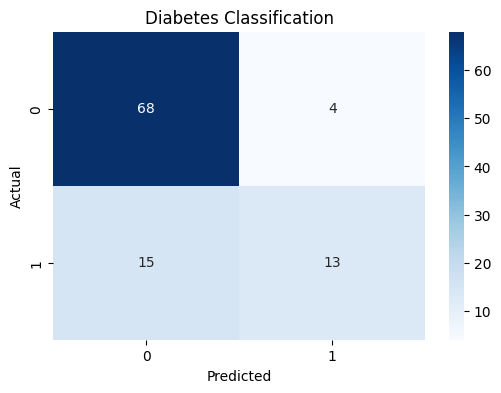

In [29]:
from sklearn.metrics import confusion_matrix

conf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf, annot=True, cmap='Blues', fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Diabetes Classification')
plt.show()

In [30]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X2, y2 = oversample.fit_resample(X, y)

In [31]:
X2_scaled = (X2 - X2.min()) / (X2.max() - X2.min())
X2_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.076923,0.232394,0.411765,0.301887,0.260726,0.314286,0.074275,0.000000
1,0.230769,0.154930,0.176471,0.471698,0.240924,0.406349,0.147645,0.119048
2,0.384615,0.774648,0.500000,0.226415,0.528053,0.241270,0.454710,0.714286
3,0.000000,0.436620,0.676471,0.754717,0.709571,0.876190,0.422101,0.238095
4,0.076923,0.415493,0.470588,0.433962,0.267327,0.520635,0.402174,0.261905


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X2_scaled, y2, test_size=0.3, stratify=y2)

In [34]:
model2 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model2.fit(X_train, y_train)
print("개선된 모델 분류 정확도: ", model2.score(X_test, y_test))

개선된 모델 분류 정확도:  0.7622377622377622


In [36]:
from sklearn import metrics
y_pred = model2.predict(X_test)
print("개선된 모델 성능 평가:", metrics.accuracy_score(y_test, y_pred))

개선된 모델 성능 평가: 0.7622377622377622


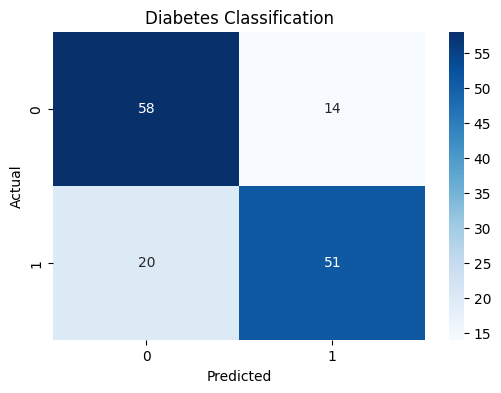

In [37]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6,4))
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf,annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Diabetes Classification')
plt.show()

In [38]:
from google.colab import files
uploaded = files.upload()

Saving new_diabetes.csv to new_diabetes.csv


In [39]:
df_new = pd.read_csv('/content/new_diabetes.csv')
df_new.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,10,168,74,30,100,38.0,0.537,34
1,4,129,86,20,270,35.1,0.231,23
2,7,155,54,35,180,30.5,0.588,40
3,2,75,64,25,50,29.7,0.370,33
4,1,99,65,16,55,23.6,0.666,27


In [40]:
df_new_scaled = (df_new-X2.min())/(X2.max()-X2.min())
df_new_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.769231,0.788732,0.529412,0.433962,0.280528,0.628571,0.409420,0.309524
1,0.307692,0.514085,0.705882,0.245283,0.841584,0.536508,0.132246,0.047619
2,0.538462,0.697183,0.235294,0.528302,0.544554,0.390476,0.455616,0.452381
3,0.153846,0.133803,0.382353,0.339623,0.115512,0.365079,0.258152,0.285714
4,0.076923,0.302817,0.397059,0.169811,0.132013,0.171429,0.526268,0.142857


In [41]:
print(model2.predict(df_new_scaled))

[1 1 1 0 0]
